**CUSTOMER CHURN ANALYSIS - BRAZILIAN E-COMMERCE** 
* Tools- SQL,PYTHON
* Dataset- Olist E-Commerce (Kaggle)
* Goal- Identify customers at risk of churning and surface actionable retention strategies

**Raw Kaggle Data → SQL Cleaning → Derived Churn Table → EDA → Modelling → Insights**

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sachithb/churn-analysis/master.csv
/kaggle/input/datasets/sachithb/churn-analysis/orders.csv
/kaggle/input/datasets/sachithb/churn-analysis/churn.csv


In [2]:
import numpy as np
churn = pd.read_csv('/kaggle/input/datasets/sachithb/churn-analysis/churn.csv')
churn

,customer_unique_id,recency,frequency,monetary,avg_review,has_review,churn
0,001ae44fa04911a9e9577356dce6c63c,329,1,116.23,NaN,0,1
1,003035f5ec76f2220098377482de93c9,399,1,62.47,NaN,0,1
2,0033f4a2887e07e25aa1204d482f41ba,97,1,425.04,NaN,0,0
3,00370dfde3d012c420d29657afc2fc8b,245,1,237.00,NaN,0,1
4,003ae409f37c3c30cb1c974af3a42692,47,1,216.32,NaN,0,0
...,...,...,...,...,...,...,...
995,23a9436c10d77a5f040576597077d6aa,311,1,965.70,NaN,0,1
996,23bb341bdc817c53a6af9a5724382cb2,84,1,157.88,NaN,0,0
997,23c9e1e8b1d0ab7a50970f0f8090f7bc,100,1,121.82,NaN,0,0
998,23d7011ee3b2d9f4a392b72077522fcf,269,1,197.20,NaN,0,1


The churn dataset has multiple features which we will be using for analysis
* The **customer_unique_id** is the id given to each customer who places an order
* **Recency** is the number of days since the last order placed by the customer
* **Frequency** is the number of times a customer has placed an order
* Some of the orders have reviews which will be helpful to calculate how the products are

**Churn** is defined when a customer stops using the product in this case the customer has stopped placing order.
* Churn is an important factor for a business as it directly defines customer satisfaction, brand loyalty and overall business health.
* A high churn rate shows poor product fit and it significantly influences revenue

In this project we have defined churn such that when the recency is greater than 180 days then the churn is 1 which means the customer has not ordered recently. 
* We have taken this threshold because as a customer who buys products in this dataset the products are the ones which are not used on a daily basis so ordering once in 6 months is considered beneficial.


In [3]:
master= pd.read_csv('/kaggle/input/datasets/sachithb/churn-analysis/master.csv')
master

,customer_unique_id,order_id,order_purchase_timestamp,payment_value,review_score,product_category_name
0,3af91c25f393301d27ccd39bce43f29d,23f10f509600c30cf2852f9dbdf28fc3,2018-05-09 10:36:28,103.49,NaN,cool_stuff
1,7d409442d2f22a2d058c1d1a19615324,fa2ea4b6e84c1c0fc4f3a6d468c55183,2018-03-20 22:27:08,227.12,NaN,cool_stuff
2,91447a501ba52792405383556f602884,ce7cf6dd8f80dfb98716950ae40eca59,2018-08-11 12:49:15,171.75,NaN,pet_shop
3,91447a501ba52792405383556f602884,ce7cf6dd8f80dfb98716950ae40eca59,2018-08-11 12:49:15,171.75,NaN,pet_shop
4,91447a501ba52792405383556f602884,ce7cf6dd8f80dfb98716950ae40eca59,2018-08-11 12:49:15,171.75,NaN,pet_shop
...,...,...,...,...,...,...
995,14a43f45c3987928d91bc11f6e468fb0,2e93a6eb72860427a8dd780b12618992,2017-04-01 18:39:34,133.19,NaN,consoles_games
996,e4f8995d1c02567ac653a0016a2a195b,61450e6c8f56d52e46a198e57df7d731,2017-11-29 07:40:23,252.09,NaN,cool_stuff
997,690a774843b58b05642f0968f0299521,aff043b28dfff4c65665fb42597daf94,2018-01-04 00:19:58,180.71,NaN,cool_stuff
998,b772c9cfe71a8b12e2217034af71ae23,c531e20fbbaf3e7302ff967fb3c7340b,2017-07-30 23:10:56,636.74,NaN,cool_stuff


The master dataset consists details of the orders 
* **Payment_value** gives us the amount spent on each order
* **Category_name** tells us to which category the product belongs to

In [4]:
orders= pd.read_csv('/kaggle/input/datasets/sachithb/churn-analysis/orders.csv')
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approved_date,delivered_date,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,10.0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,24.0,7.0,14.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,8.0,17.0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,18.0,2.0,15.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,13.0,16.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...
995,e2493d49c7ac426207fb7575814ebbd4,660e0dca520294ab5ff435d0298627f9,delivered,2017-12-04 17:16:55,2017-12-04 18:30:31,2017-12-05 21:37:09,2017-12-21 21:17:08,2018-01-09 00:00:00,4.0,21.0,17.0
996,be6e034d294e425c514e215bf0b7120a,ba7c84cd4d0db9d73b66a79e4d3e130c,delivered,2017-05-22 15:57:42,2017-05-22 16:05:19,2017-05-24 08:17:48,2017-05-30 12:13:30,2017-06-09 00:00:00,22.0,30.0,8.0
997,777ee9a9950b655601a65012d4e45584,14e5f1e56b5d74d9fe35c39e8ba04699,delivered,2017-10-08 14:53:58,2017-10-08 15:07:11,2017-10-09 20:17:55,2017-10-13 21:36:49,2017-11-01 00:00:00,8.0,13.0,5.0
998,f056d4857c146c38ff02566b3e152bca,fc6408fa8083f3c01b1f287709714321,delivered,2018-05-17 16:37:03,2018-05-18 02:54:16,2018-05-18 14:35:00,2018-05-22 02:40:39,2018-06-07 00:00:00,17.0,22.0,5.0


The orders dataset has the details of the product delivery details 
* **Delivery_days** give us the number of days taken to deliver the product

In [5]:
churn.info()
churn.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  1000 non-null   object 
 1   recency             1000 non-null   int64  
 2   frequency           1000 non-null   int64  
 3   monetary            1000 non-null   float64
 4   avg_review          28 non-null     float64
 5   has_review          1000 non-null   int64  
 6   churn               1000 non-null   int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 54.8+ KB


,recency,frequency,monetary,avg_review,has_review,churn
count,1000.000000,1000.000000,1000.000000,28.000000,1000.000000,1000.000000
mean,315.813000,1.008000,194.382600,4.250000,0.028000,0.774000
std,152.353995,0.099729,251.531934,1.040833,0.165055,0.418448
min,36.000000,1.000000,13.380000,1.000000,0.000000,0.000000
25%,190.750000,1.000000,71.907500,4.000000,0.000000,1.000000
50%,311.000000,1.000000,130.250000,5.000000,0.000000,1.000000
75%,440.000000,1.000000,218.272500,5.000000,0.000000,1.000000
max,727.000000,3.000000,2837.340000,5.000000,1.000000,1.000000


### Basic KPIs

In [6]:
churn_rate = churn['churn'].mean() * 100
print(churn_rate,'%')

77.4 %


**Churn rate is 77.4%, which tells us that 77 percent of customers have not placed an order recently, which is bad for the business, as retention of the customers is one of the most important factors of a profitable business**

In [7]:
avg_spent = churn['monetary'].mean()
print(avg_spent)

194.3826


**194 is the average amount a customer spends on an order**

In [8]:
avg_freq = churn['frequency'].mean()
print(avg_freq)

1.008


**The average frequency tells us the number of times a user places an order on average and 1.008 is considerably low. A higher average frquency is an indicator of a good business**

In [9]:
churn['churn'] = churn['churn'].astype(int)

In [10]:
churn.groupby('churn').mean(numeric_only=True)

,recency,frequency,monetary,avg_review,has_review
churn,,,,,
0,112.920354,1.004425,197.089336,3.500000,0.026549
1,375.055556,1.009044,193.592261,4.454545,0.028424


This metrics gives us the average values of all the factors and is grouped by the churn value

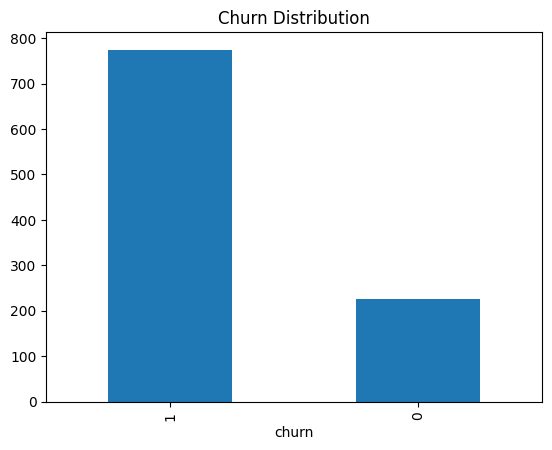

In [11]:
import matplotlib.pyplot as plt

# Churn distribution
churn['churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()

**From this graph, we can see that the majority of the customers have churned, and this affects the business model.**
* This affects the business model because the revenue keeps on decreasing every month and the forecasting becomes unreliable (inventory planning,warehouse costs)
* The business has to spend more on marketing to reach new customers 
* The brand loyalty is weak as the customers rarely come back.


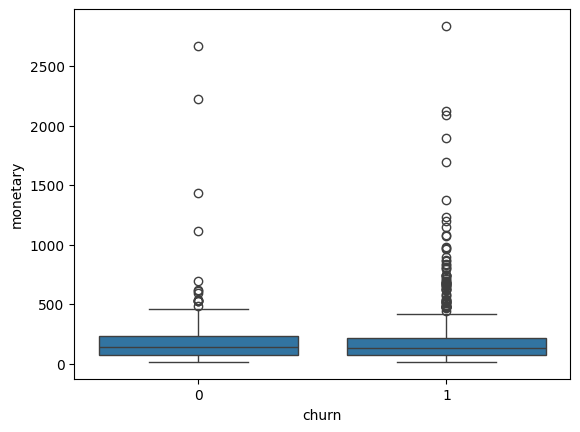

In [12]:
import seaborn as sns

sns.boxplot(x='churn', y='monetary', data=churn)
plt.show()

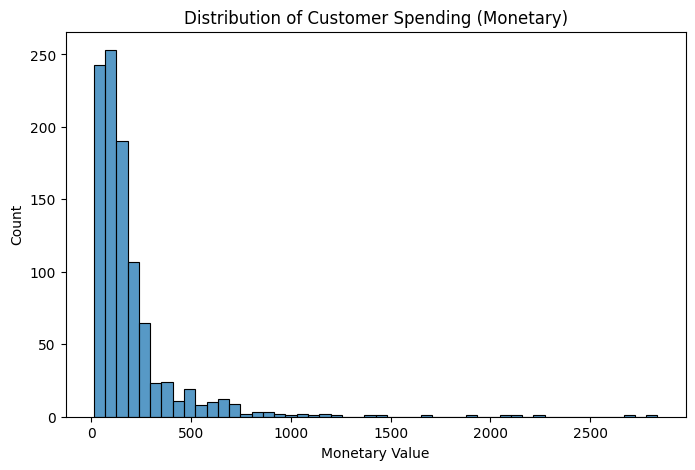

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.histplot(churn['monetary'], bins=50)
plt.title("Distribution of Customer Spending (Monetary)")
plt.xlabel("Monetary Value")
plt.show()

* From the above graph we can see that most of the customers spend in the range of 50 to 250 dollars and it can be categorized into low to mid value spending 
* As the low value spending exists the profit margins are also small and the customers must return back to keep the business profitable
* The churn being 77% the comapny faces a serious issue regarding profitability

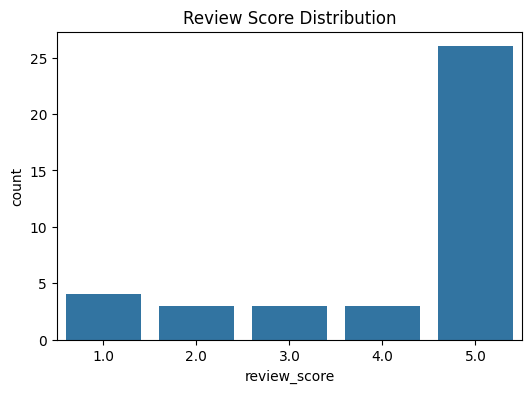

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='review_score', data=master)
plt.title("Review Score Distribution")
plt.show()

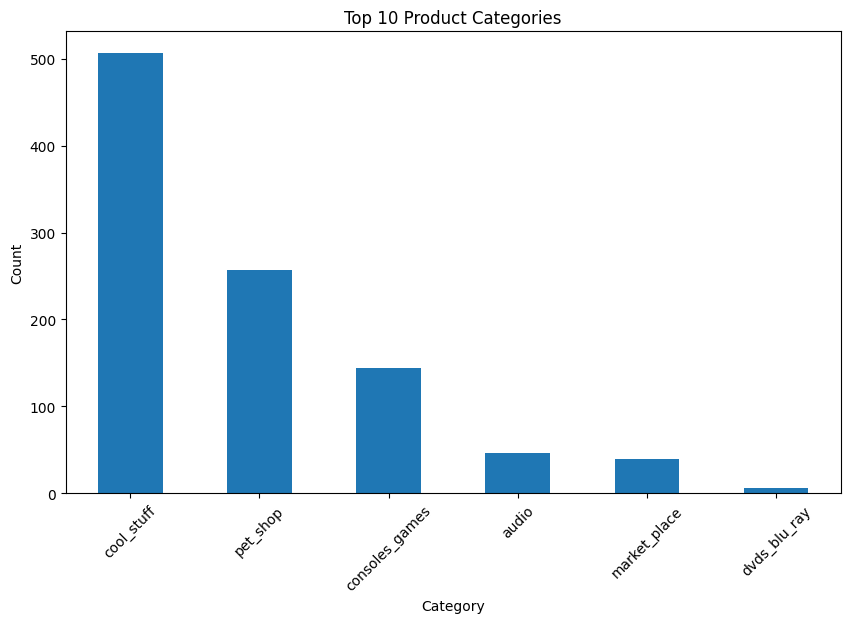

In [15]:
top_categories = master['product_category_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_categories.plot(kind='bar')
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

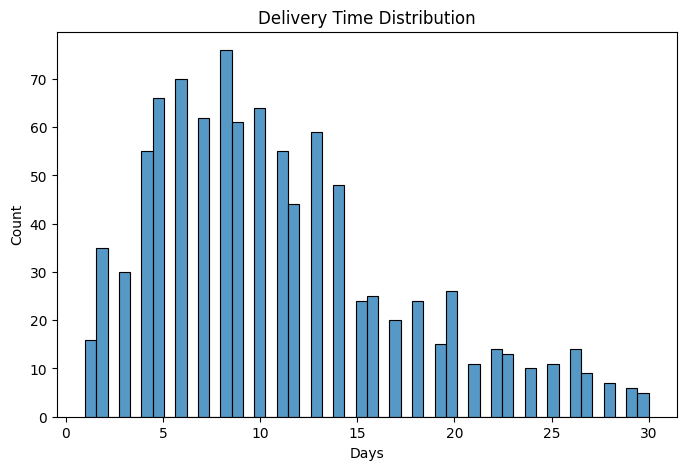

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(orders['delivery_days'], bins=50)
plt.title("Delivery Time Distribution")
plt.xlabel("Days")
plt.show()

* The delivery days tell us one important issue, which is that the product is being delivered within 2 weeks of order, and this is considered good enough for an e-commerce business
* Delivery being good enough, still the customer is not satisfied and gets churned
* Then the problem becomes the product itself, which is not up to the expectations of the customer
* When expectations are not met, customers never come back to order again, which leads to the customer getting churned 

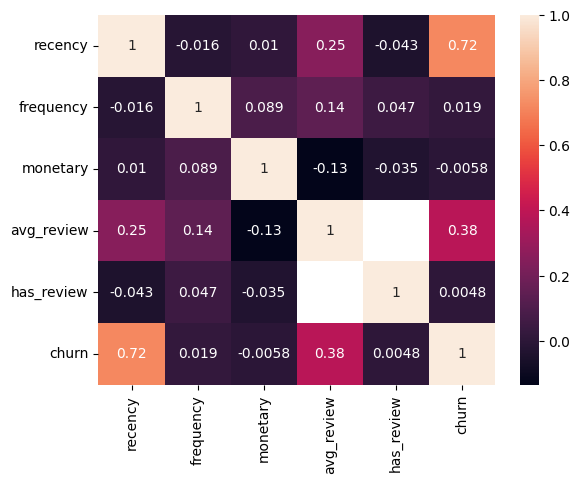

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_churn = churn.select_dtypes(include=['number'])
sns.heatmap(numeric_churn.corr(), annot=True)
plt.show()

From the above correlation map, we can figure out
* **As the recency increases the churn probability also increases**
* **Even though the average review score is 0.38, the churn rate is high.**
  
This might be because only the customers who are satisfied give the reviews, and hence the 5-star ratings are high, and the customers who completely disliked the product give 1 star, which can be seen in the reviews count graph. Therefore, without having the complete data of the reviews a proper conclusion on the reviews vs churn cannot be drawn. 

In [18]:
churn = churn.drop(columns=['customer_unique_id'])

In [19]:
X = churn.drop('churn', axis=1)
y = churn['churn']

In [20]:
X = churn.drop(['churn', 'recency'], axis=1)

In [21]:
X.head()

,frequency,monetary,avg_review,has_review
0,1,116.23,NaN,0
1,1,62.47,NaN,0
2,1,425.04,NaN,0
3,1,237.00,NaN,0
4,1,216.32,NaN,0


In [27]:
X['avg_review'] = X['avg_review'].fillna(0)

In [28]:
X['avg_review'] = X['avg_review'].fillna(X['avg_review'].median())

In [29]:
print(X.isnull().sum())
print(f"Total NaN values: {X.isnull().sum().sum()}")

frequency     0
monetary      0
avg_review    0
has_review    0
dtype: int64
Total NaN values: 0


In [30]:
X.sample(5)

,frequency,monetary,avg_review,has_review
438,1,156.16,0.0,0
497,1,43.75,0.0,0
843,1,154.10,0.0,0
357,1,34.53,0.0,0
39,1,305.70,0.0,0


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, 
                              RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [32]:
X['avg_review'] = X['avg_review'].fillna(0)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
lr  = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf  = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [35]:
models = {"Logistic Regression": lr, "Random Forest": rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.27      0.44      0.34        45
           1       0.80      0.66      0.72       155

    accuracy                           0.61       200
   macro avg       0.54      0.55      0.53       200
weighted avg       0.68      0.61      0.64       200

ROC-AUC: 0.5180

────────────────────────────────────────
  Random Forest
────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.46      0.42      0.44        45
           1       0.84      0.86      0.85       155

    accuracy                           0.76       200
   macro avg       0.65      0.64      0.64       200
weighted avg       0.75      0.76      0.76       200

ROC-AUC: 0.7051


Logistic Regression

Logistic Regression works by learning a linear relationship between input features and the log-odds of the target variable (churn)

* It tries to learn how the features in the dataset influence the model
* It builds an equation and calculates the probability between 0 and 1
* If the probability is above 0.5 then it calculates the churn as 1. Most of the time the model defaults to predict churn as 1
* But from the correlation diagram, we can see that the features barely influence the churn
* As the churn count is high, the model learns and becomes skewed.
So, without the recency parameter in the dataset, churn is hard to predict. After the removal of the recency parameter, the other features have a weak correlation with churn so the model has a poor predictive model

**Random Forest** 
Random Forest was used as a non-linear ensemble model to predict customer churn. Random Forest builds multiple decision trees on different subsets of the data and combines their predictions. The final prediction is made using the majority voting across. 
* The model selects a random subset for each iteration, which reduces overfitting
* The ROC-AUC is 0.7 which is decent enough and proves that it is not linear and shows why the logistic regression failed
* The model is very good at catching churners as the recall is 0.86
* The model struggles in predicting non churners as the training dataset is skewed towards churners and the model learns this.

We can solve this by having an even larger data set so that the training is balanced enough to learn the churning rate so that the model predicts properly 

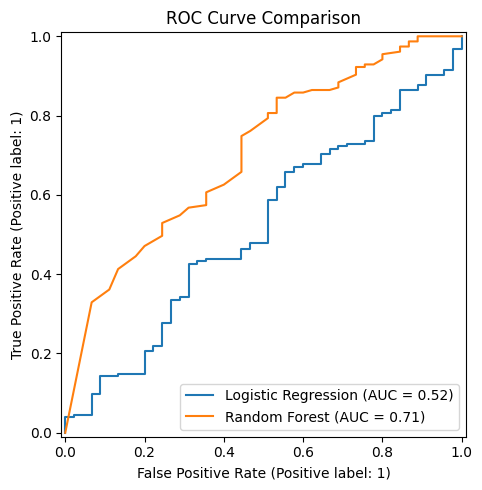

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

The ROC-AUC comparison showed that the Random Forest model significantly outperformed Logistic Regression. Logistic Regression achieved an AUC score of 0.52, indicating near-random classification performance, while Random Forest achieved an AUC score of 0.71, demonstrating better capability in distinguishing churn and non-churn customers. This suggests that customer churn behavior in the dataset follows non-linear patterns better captured by ensemble tree-based methods

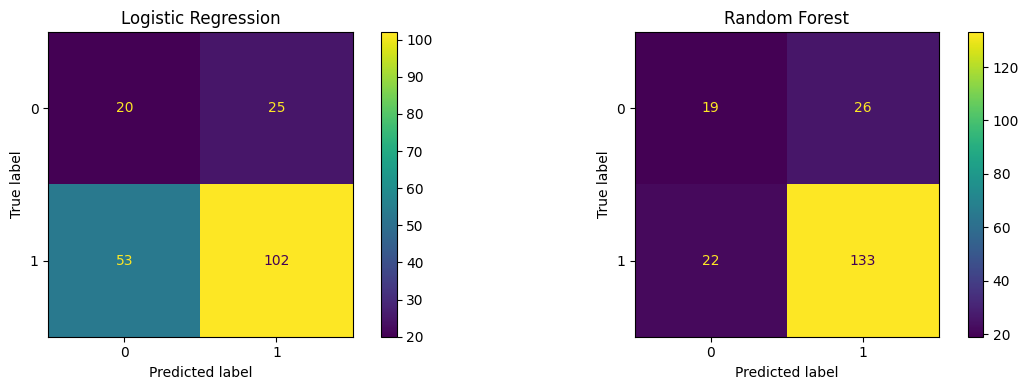

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

The ROC-AUC comparison showed that the Random Forest model significantly outperformed Logistic Regression. Logistic Regression achieved an AUC score of 0.52, indicating near-random classification performance, while Random Forest achieved an AUC score of 0.71, demonstrating better capability in distinguishing churn and non-churn customers. This suggests that customer churn behavior in the dataset follows non-linear patterns better captured by ensemble tree-based methods

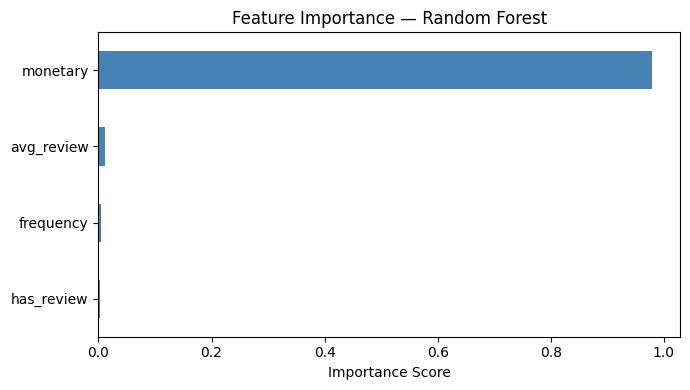

In [38]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7, 4))
feat_imp.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

**Business Recommendations 1**
* Create trigger automated re-engagement campaigns (email or discounts) at 120-150 days before the customer crosses the point of no return.
* This is the single highest-impact intervention because the model can't act on customers who have already churned.
* By this the customer can be influenced to order again and make sure the customer isnt churned 

**Business Recommendation 2**
* Losing a high-value customer who spends more than 300 dollars hurts more than losing a low-value customer spending 60 dollars
* The churn rate has to be segmented and make sure the top 25% customers are offered a win-back offer so that they arent churned
* This is because high-value customers generate more ROI and profit than the low-value customers
* Hence a more comprehensive strategic way has to be developed to make sure the high-value at risk customers arent churned 

**Business Recommendation 3**
* 64% of the customers havent left a review for the product they purchased.
* This shows that the process of reviewing is tedious and the customers are skipping this step
* Reviews are very important in business as they represent customer satisfaction or dissatisfaction and this is very important to a business
* A single click review process should be introduced which is seamless and takes less than 5 seconds for the customers to review
* We can also add small incentives in the beginning to customers who leave a review about the product in this way more customers review the product
* By this in 3 months the reviews data will be full and we can use that predict and model the predictor in a better way as customer satisfaction is a known churn predictor in e-commerce literature